In [1]:
!pip install feature-engine --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 5.8 MB/s eta 0:00:00


In [12]:
import pandas as pd
import numpy as np

def load_titanic():
    # 1. Veriyi çek
    url = 'https://www.openml.org/data/get_csv/16826755/phpMYEkMl'
    data = pd.read_csv(url)

    # 2. '?' işaretlerini gerçek boş değer (NaN) ile değiştir
    data = data.replace('?', np.nan)

    # 3. SAYIYA ÇEVİRME (Hatanın çözümü burada)
    # Age ve Fare sütunlarını zorla sayıya çeviriyoruz, çevrilemeyenler NaN olur
    data['age'] = pd.to_numeric(data['age'], errors='coerce')
    data['fare'] = pd.to_numeric(data['fare'], errors='coerce')

    # 4. Boş değerleri MEDYAN ile doldur
    # Sayıya çevirdiğimiz için artık median() hata vermeyecek
    data['age'] = data['age'].fillna(data['age'].median())
    data['fare'] = data['fare'].fillna(data['fare'].median())

    # 5. Diğer düzenlemeler
    data['cabin'] = data['cabin'].astype(str).str[0] # Kabin numarasının ilk harfi
    data['pclass'] = data['pclass'].astype('O')     # Sınıf bilgisini kategorik yap
    data['embarked'] = data['embarked'].fillna('C')  # Eksik liman bilgisini doldur

    # 6. Gereksiz sütunları at
    data = data.drop(labels=['boat', 'body', 'home.dest', 'name', 'ticket'], axis=1)

    return data

# Çalıştıralım
data = load_titanic()
print(data.head())

  pclass  survived     sex      age  sibsp  parch      fare cabin embarked
0      1         1  female  29.0000      0      0  211.3375     B        S
1      1         1    male   0.9167      1      2  151.5500     C        S
2      1         0  female   2.0000      1      2  151.5500     C        S
3      1         0    male  30.0000      1      2  151.5500     C        S
4      1         0  female  25.0000      1      2  151.5500     C        S


In [13]:
# let's separate into training and testing set
X = data.drop(['survived'], axis=1)
y = data.survived

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)

print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

X_train : (916, 8)
X_test : (393, 8)


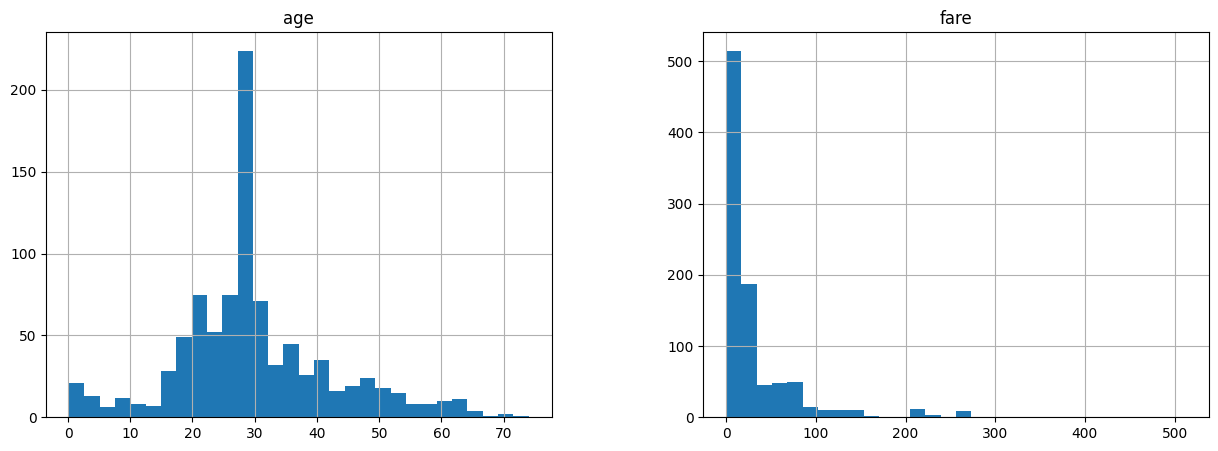

In [14]:
# we will transform two continuous variables
X_train[["age", 'fare']].hist(bins=30)
plt.show()

1️⃣ ArbitraryDiscretiser kurulumu
age ve fare sütunlarını belli aralıklara böldük.

Örneğin age için: 0–18, 18–30, 30–50, 50–100 yaş aralıkları.

fare için: -1–20, 20–40, … 80–600.

return_object=True → sonucu kategori (object) olarak döndürür, sayısal değil.

💡 Amaç: Sürekli değişkenleri modelin daha kolay anlayacağı discrete (kategorik) değişkenlere çevirmek.

In [17]:
arb_disc = ArbitraryDiscretiser(
    binning_dict={'age': [0, 18, 30, 50, 100],
                  'fare': [-1, 20, 40, 60, 80, 600]},
    # returns values as categorical
    return_object=True)

Burada age ve fare artık kategorik hâle geldi.

MeanEncoder, her kategori için hedef değişkenin (örn. y_train) ortalamasını hesaplayıp o kategoriye atar.

Örneğin age = 18–30 olan bütün satırlar, y_train’deki hedef ortalaması ile değiştirilecek.

💡 Amaç: Kategorik değişkeni hedef ile monotonik bir sayıya çevirmek, lineer modellerin daha iyi öğrenmesini sağlamak.

Kısaca:

Sürekli değişkenleri kategorilere böldük → kategorileri hedef ortalaması ile encode ettik → lineer model için hazır hâle getirdik.

In [18]:
mean_enc = MeanEncoder(variables=['age', 'fare'])

In [19]:
transformer = Pipeline(steps=[('ArbitraryDiscretiser', arb_disc),
                              ('MeanEncoder', mean_enc),
                              ])

In [20]:
transformer.fit(X_train, y_train)

Pipeline(steps=[('ArbitraryDiscretiser',
                 ArbitraryDiscretiser(binning_dict={'age': [0, 18, 30, 50, 100],
                                                    'fare': [-1, 20, 40, 60, 80,
                                                             600]},
                                      return_object=True)),
                ('MeanEncoder', MeanEncoder(variables=['age', 'fare']))])

In [21]:
transformer.named_steps['ArbitraryDiscretiser'].binner_dict_

{'age': [0, 18, 30, 50, 100], 'fare': [-1, 20, 40, 60, 80, 600]}

In [22]:
transformer.named_steps['MeanEncoder'].encoder_dict_

{'age': {0: 0.45081967213114754,
  1: 0.34309623430962344,
  2: 0.4262948207171315,
  3: 0.4153846153846154},
 'fare': {0: 0.288135593220339,
  1: 0.43283582089552236,
  2: 0.5636363636363636,
  3: 0.45652173913043476,
  4: 0.7349397590361446}}

In [23]:
train_t = transformer.transform(X_train)
test_t = transformer.transform(X_test)

test_t.head()

,pclass,sex,age,sibsp,parch,fare,cabin,embarked
1139,3,male,0.426295,0,0,0.288136,n,S
533,2,female,0.343096,0,1,0.432836,n,S
459,2,male,0.426295,1,0,0.432836,n,S
1150,3,male,0.343096,0,0,0.288136,n,S
393,2,male,0.343096,0,0,0.432836,n,S


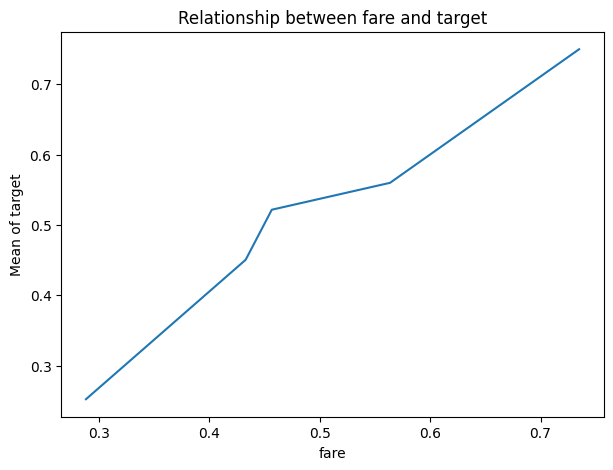

In [24]:
# let's explore the monotonic relationship
plt.figure(figsize=(7, 5))
pd.concat([test_t, y_test], axis=1).groupby("fare")["survived"].mean().plot()
plt.title("Relationship between fare and target")
plt.xlabel("fare")
plt.ylabel("Mean of target")
plt.show()